# Notebook 09 — Soil parameters W<sub>m</sub> and K, derived **entirely from IGAC**

**Goal.** Give every minibacia the two soil parameters the MGB-SA model needs:

- **W<sub>m</sub>** — the *maximum water the soil column can store* (mm). Controls how much rain infiltrates before
  saturation-excess runoff begins. The single most important water-balance soil parameter.
- **K** — the *MUSLE soil erodibility* (how easily rain and runoff detach soil). Directly multiplies the sediment yield.

**Key decision.** Both come from the **IGAC field survey** — the same free-text soil descriptions we used for the
texture family in notebook 08 — **not** from SoilGrids pedotransfer. This notebook explains *why* that matters,
parameter by parameter, computes both, and **validates K against the measured sediment rating curves**.

Inputs (all from notebook 07/08 + `src/build_soil_layer.py`):
`minibacias.tif`, `soil_family_igac.tif`, `soil_depth_igac.tif`, `soil_drainage_igac.tif` (+ SoilGrids rasters, used
only to *demonstrate the problem*).

## 1 — The problem: why not the SoilGrids pedotransfer?

A **pedotransfer function (PTF)** is an empirical formula that turns *measured soil properties* (texture %, organic
carbon, bulk density) into a *hydrological parameter* we cannot measure directly (W<sub>m</sub>, K, conductivity…).
The classic route is: **SoilGrids clay/sand/silt → PTF → W<sub>m</sub>, K**. That looks rigorous, but here it fails,
and it fails **differently** for each parameter:

| | W<sub>m</sub> (storage) | K (erodibility) |
|---|---|---|
| **What it needs** | available-water capacity **× soil depth** | texture + structure + permeability |
| **SoilGrids problem** | texture is a near-uniform ML artefact (**~95 % "Fine"**, clay 33±4 %) **and SoilGrids has no soil-depth layer at all** | same uniform texture → **uniform K**, erasing the erodibility contrast |
| **Consequence** | W<sub>m</sub> would be ~constant across the basin (wrong) | sediment source map would be flat (fatal for a sediment study) |
| **Can calibration save it?** | partly — W<sub>m</sub> is a calibration knob, bias is *recoverable* | **no** — K is not freely calibrated; bias flows straight into Qs |
| **Extra flaw** | — | classifying the URH from IGAC but taking K from SoilGrids is *internally inconsistent* |

**Why IGAC fixes both.** The IGAC description carries **texture, depth *and* drainage** in words
(*"moderadamente profundos, bien drenados, texturas medias a finas"*). So we get (a) real **depth** → real
W<sub>m</sub> variation, (b) field-mapped **texture** → real K contrast, and (c) full **consistency** with the URH
classification. The cell below shows the SoilGrids uniformity that motivates the switch.

In [1]:
import glob, tempfile, pathlib, shutil
import numpy as np, pandas as pd, rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches, matplotlib.pyplot as plt
%matplotlib inline

REPO=None
for b in [pathlib.Path.cwd()]+list(pathlib.Path.cwd().parents):
    if (b/'data'/'processed'/'minibacias.tif').exists(): REPO=b; break
REPO=REPO or pathlib.Path.cwd(); proc=REPO/'data'/'processed'; SOIL=str(REPO/'data'/'raw'/'soils')
def rd(name):
    with rasterio.open(proc/name) as s:
        a=s.read(1); tr=s.transform; b=s.bounds
    return a,tr,[b.left,b.right,b.bottom,b.top]
subs,tr,extent = rd('minibacias.tif')
fam,_,_  = rd('soil_family_igac.tif')     # 1 Coarse 2 Medium 3 Fine
dep,_,_  = rd('soil_depth_igac.tif')      # cm (0 = not stated)
drn,_,_  = rd('soil_drainage_igac.tif')   # 1 well 2 moderate 3 poor (0 = not stated)
H,W = subs.shape; bas = subs>0
FAM={1:'Coarse',2:'Medium',3:'Fine'}; FCOL={1:'#E7C98F',2:'#C7A06A',3:'#6B4E2E'}
print('grid',H,W,'| basin cells',int(bas.sum()),'| minibacias',int(np.unique(subs[bas]).size))
print('texture stated %.0f%% | depth %.0f%% | drainage %.0f%%'%(100*np.mean(fam[bas]>0),100*np.mean(dep[bas]>0),100*np.mean(drn[bas]>0)))

grid 1500 705 | basin cells 472438 | minibacias 8672
texture stated 98% | depth 83% | drainage 80%


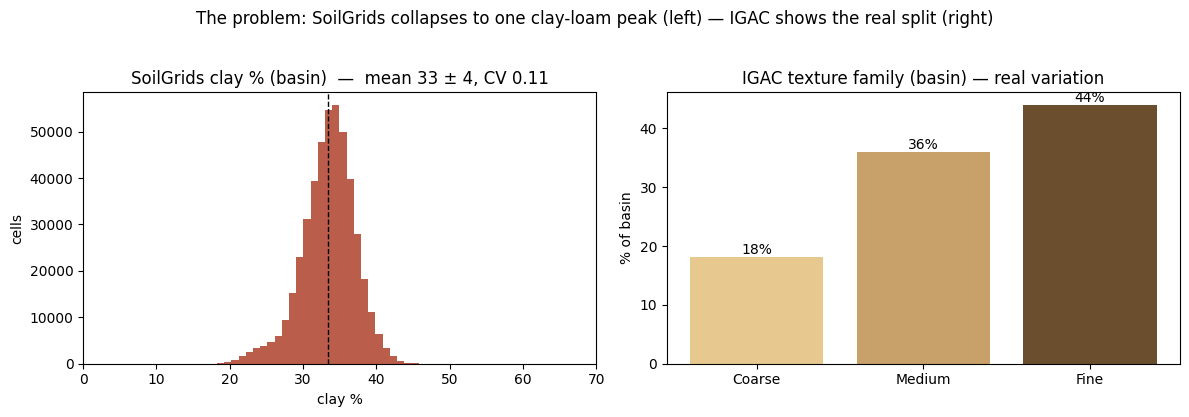

SoilGrids clay coefficient of variation = 0.11  (near-constant -> a PTF on it returns near-constant Wm and K)


In [2]:
# ---- demonstrate the SoilGrids uniformity that makes its PTF unusable here ----
def sg(n):
    with rasterio.open(SOIL+f"/soilgrids_{n}.tif") as s:
        o=np.zeros((H,W),'float32'); reproject(rasterio.band(s,1),o,dst_transform=tr,dst_crs="EPSG:4326",resampling=Resampling.bilinear)
    return o
clay=sg('clay')/10.; sand=sg('sand')/10.; silt=sg('silt')/10.
vv=(clay>0)&(sand>0)&(silt>0)&bas
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].hist(clay[vv],bins=40,color='#B0412B',alpha=.85)
ax[0].axvline(np.mean(clay[vv]),color='k',ls='--',lw=1)
ax[0].set_title('SoilGrids clay %% (basin)  —  mean %.0f ± %.0f, CV %.2f'%(np.mean(clay[vv]),np.std(clay[vv]),np.std(clay[vv])/np.mean(clay[vv])))
ax[0].set_xlabel('clay %'); ax[0].set_ylabel('cells'); ax[0].set_xlim(0,70)
sh=[100*np.mean(fam[bas]==k) for k in (1,2,3)]
ax[1].bar([FAM[k] for k in (1,2,3)],sh,color=[FCOL[k] for k in (1,2,3)])
ax[1].set_title('IGAC texture family (basin) — real variation'); ax[1].set_ylabel('% of basin')
for i,v in enumerate(sh): ax[1].text(i,v+0.5,'%.0f%%'%v,ha='center')
plt.suptitle('The problem: SoilGrids collapses to one clay-loam peak (left) — IGAC shows the real split (right)',y=1.03)
plt.tight_layout(); plt.show()
print('SoilGrids clay coefficient of variation = %.2f  (near-constant -> a PTF on it returns near-constant Wm and K)'%(np.std(clay[vv])/np.mean(clay[vv])))

## 2 — Prepare the IGAC inputs (fill the small unstated fraction)

A few polygons don't state depth or drainage. We fill **depth** with the *median stated depth of the same texture
family* (a soil-type-consistent default, not a blanket constant) and **drainage** with *well-drained* (the basin mode,
55 %). Both fills touch <20 % of cells and are the most neutral choice.

In [3]:
dep_f=dep.astype('float32').copy()
for k in (1,2,3):
    med=np.median(dep[(fam==k)&bas&(dep>0)]) if np.any((fam==k)&bas&(dep>0)) else 60
    dep_f[(fam==k)&bas&(dep<=0)]=med
dep_f[bas&(dep_f<=0)]=60           # any remaining
drn_f=drn.copy(); drn_f[bas&(drn_f==0)]=1
print('depth after fill: median %.0f cm, range %.0f–%.0f'%(np.median(dep_f[bas]),dep_f[bas].min(),dep_f[bas].max()))
print('drainage after fill %:',{1:round(100*np.mean(drn_f[bas]==1),0),2:round(100*np.mean(drn_f[bas]==2),0),3:round(100*np.mean(drn_f[bas]==3),0)})

depth after fill: median 37 cm, range 15–150
drainage after fill %: {1: np.float64(75.0), 2: np.float64(18.0), 3: np.float64(7.0)}


## 3 — W<sub>m</sub> (maximum soil water storage)

**Physics.** W<sub>m</sub> is the depth of water (mm) the soil can hold as *plant-available* storage. It is the product
of two things:

$$W_m \;=\; \text{AWC} \times Z \times 10$$

- **AWC** = *available water capacity* (cm³ water per cm³ soil) — the water held between **field capacity** (after
  drainage) and the **wilting point** (too tight for plants). It depends on **texture**: sandy soils drain fast (low
  AWC), loams hold the most, clays hold a lot of water but much is unavailable.
- **Z** = **effective soil depth** (cm) — from IGAC's depth words. *This is the term SoilGrids cannot provide at all.*
- ×10 converts cm of water to mm.

**AWC by texture family** (mid-range of Saxton & Rawls 2006 / FAO class values):

| Family | AWC (cm³/cm³) | rationale |
|---|---|---|
| Coarse (sandy) | 0.09 | drains fast, holds little |
| Medium (loamy) | 0.17 | optimal pore mix — holds the most |
| Fine (clayey) | 0.14 | high total water, but much below wilting point |

**Why IGAC is better here.** SoilGrids gives *no depth*, so a SoilGrids-only W<sub>m</sub> must assume a constant Z and
then varies only with its near-uniform texture → an almost flat map. IGAC's depth ranges from 15 cm (very shallow) to
150 cm (very deep), so IGAC W<sub>m</sub> captures the real storage contrast between thin mountain soils and deep valley
soils. The maps below make the difference obvious.

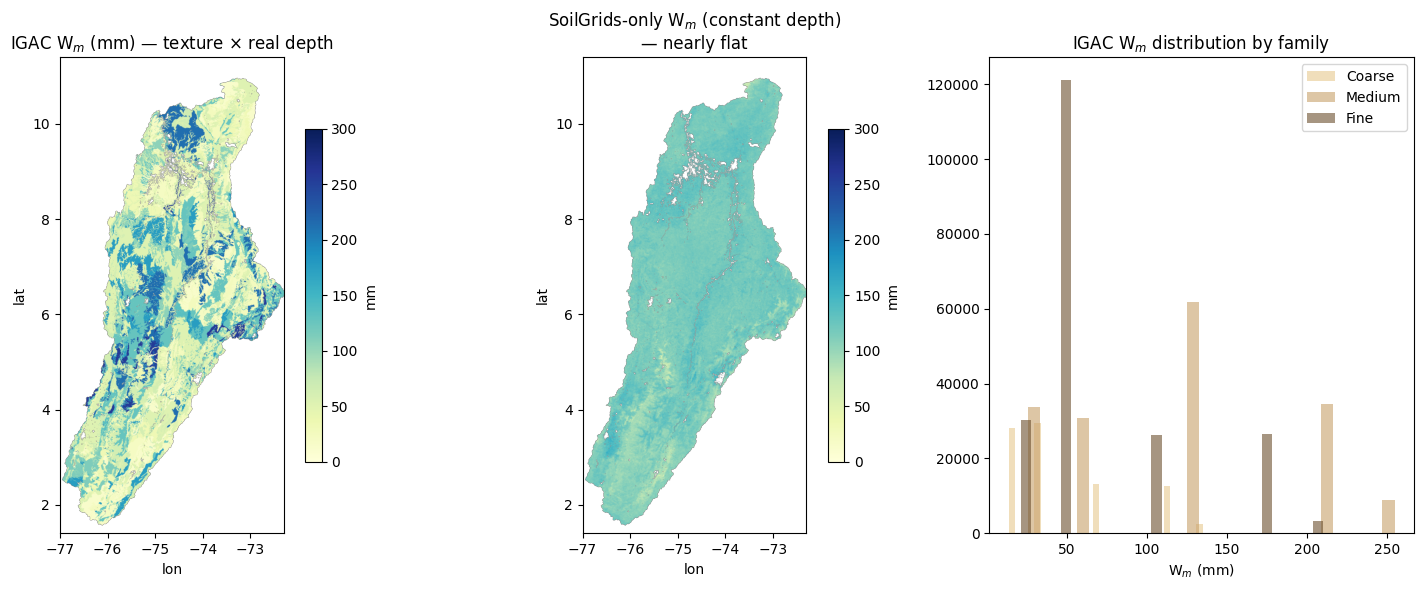

IGAC Wm: mean 85 mm, CV 0.74  (spatially variable)
SoilGrids-only Wm CV 0.08  (nearly constant — the depth term is missing)


In [4]:
AWC={1:0.09,2:0.17,3:0.14}                       # cm3/cm3 by family
awc=np.zeros((H,W),'float32')
for k in (1,2,3): awc[fam==k]=AWC[k]
Wm=np.where(bas&(fam>0), awc*dep_f*10.0, np.nan)  # mm

# SoilGrids-only Wm for contrast: AWC from continuous texture (Saxton-style), CONSTANT depth 100 cm (no SG depth layer)
awc_sg=np.clip(0.15 - 0.20*(sand/100.) + 0.10*(silt/100.), 0.03, 0.25)   # rough texture->AWC, illustrative
Wm_sg=np.where(vv, awc_sg*100.0*10.0, np.nan)

fig,ax=plt.subplots(1,3,figsize=(15,6))
im0=ax[0].imshow(np.where(bas&(fam>0),Wm,np.nan),extent=extent,cmap='YlGnBu',vmin=0,vmax=300)
ax[0].set_title('IGAC W$_m$ (mm) — texture × real depth'); plt.colorbar(im0,ax=ax[0],shrink=.7,label='mm')
im1=ax[1].imshow(Wm_sg,extent=extent,cmap='YlGnBu',vmin=0,vmax=300)
ax[1].set_title('SoilGrids-only W$_m$ (constant depth)\n— nearly flat'); plt.colorbar(im1,ax=ax[1],shrink=.7,label='mm')
for k in (1,2,3):
    d=Wm[(fam==k)&bas]; d=d[~np.isnan(d)]
    ax[2].hist(d,bins=30,alpha=.6,color=FCOL[k],label=f'{FAM[k]}')
ax[2].set_title('IGAC W$_m$ distribution by family'); ax[2].set_xlabel('W$_m$ (mm)'); ax[2].legend()
for a in ax[:2]: a.set_xlabel('lon'); a.set_ylabel('lat')
plt.tight_layout(); plt.show()
print('IGAC Wm: mean %.0f mm, CV %.2f  (spatially variable)'%(np.nanmean(Wm),np.nanstd(Wm)/np.nanmean(Wm)))
print('SoilGrids-only Wm CV %.2f  (nearly constant — the depth term is missing)'%(np.nanstd(Wm_sg)/np.nanmean(Wm_sg)))

## 4 — K (MUSLE soil erodibility)

**Physics.** K measures how easily raindrop impact and runoff *detach and transport* soil particles
(units t·ha·h·ha⁻¹·MJ⁻¹·mm⁻¹). It is highest for **silty/loamy** soils (weak aggregates, easily detached), **lowest for
coarse sand** (heavy grains, high infiltration → less runoff), and **intermediate for clay** (hard to detach once
aggregated, but runs off more). So the ordering is **Medium > Fine > Coarse**.

**K by texture family** — mid-range Wischmeier & Smith (1978) class values converted to SI (×0.1317), typical of
tropical soils:

| Family | K (SI) |
|---|---|
| Coarse | 0.020 |
| Medium | 0.045 |
| Fine   | 0.028 |

**Drainage adjustment.** The Wischmeier nomograph has a *permeability* term: slowly-permeable (poorly-drained) soils
generate more runoff → slightly higher K; well-drained soils slightly lower. We apply a modest factor
(well 0.95 · moderate 1.00 · poor 1.10) from IGAC's drainage words. It is deliberately small and can be switched off.

**Why IGAC is better here.** SoilGrids' uniform texture gives a **spatially flat K** (its EPIC/Williams K has a
coefficient of variation of only a few %), so every hillslope looks equally erodible — the sediment source map would be
meaningless. IGAC's texture + drainage restore the real contrast (erodible medium/silt soils vs resistant coarse
Andean soils). Shown below.

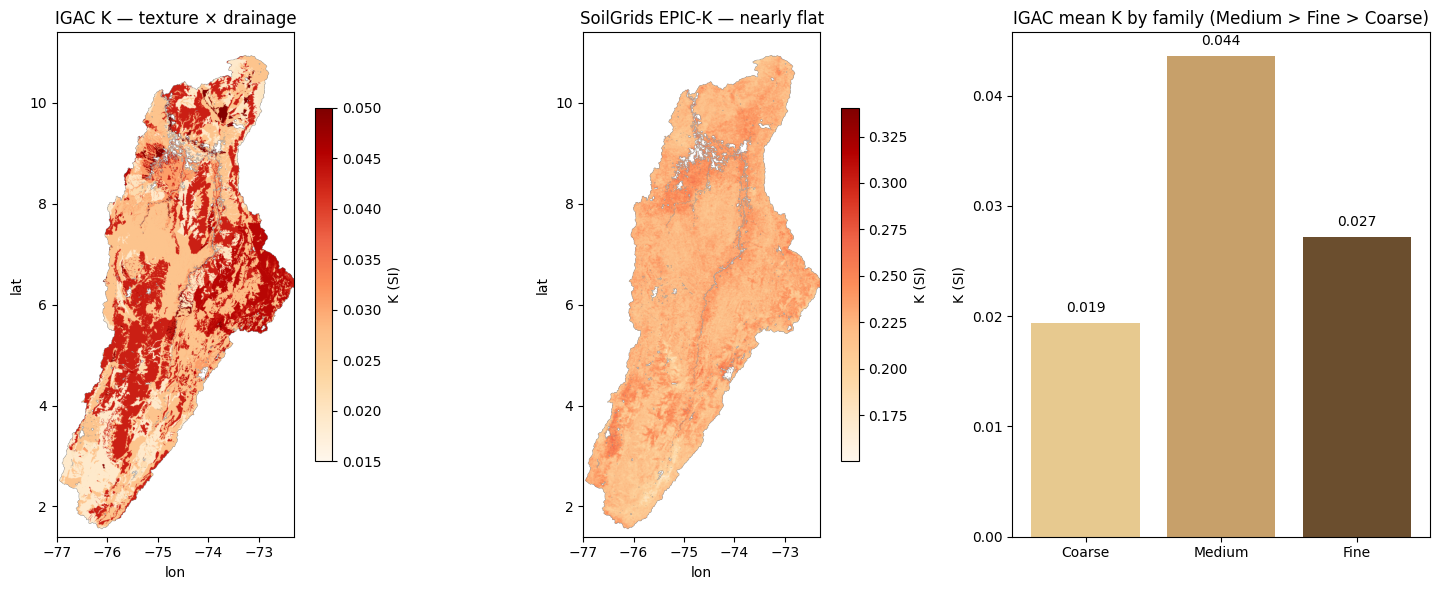

IGAC K CV 0.30  vs  SoilGrids-EPIC K CV 0.05


In [5]:
KBASE={1:0.020,2:0.045,3:0.028}; DFAC={1:0.95,2:1.00,3:1.10}
K=np.zeros((H,W),'float32')
for k in (1,2,3): K[fam==k]=KBASE[k]
kd=np.ones((H,W),'float32')
for d in (1,2,3): kd[drn_f==d]=DFAC[d]
K=np.where(bas&(fam>0), K*kd, np.nan)

# SoilGrids EPIC/Williams K for contrast (from continuous sand/silt/clay/SOC) -> show it's flat
sand_c=np.clip(sand,0,100); silt_c=np.clip(silt,0,100); clay_c=np.clip(clay,0,100)
soc=np.clip(sg('soc')/100.0,0,15)          # ~ % organic carbon (approx); clip nodata to avoid exp overflow
SN=1-sand_c/100.
with np.errstate(over='ignore',invalid='ignore'):
    Ksg=(0.2+0.3*np.exp(-0.0256*sand_c*(1-silt_c/100.)))*(silt_c/(clay_c+silt_c+1e-6))**0.3 \
        *(1-0.25*soc/(soc+np.exp(3.72-2.95*soc)))*(1-0.7*SN/(SN+np.exp(-5.51+22.9*SN)))
Ksg=np.where(vv,Ksg,np.nan)

fig,ax=plt.subplots(1,3,figsize=(15,6))
im0=ax[0].imshow(np.where(bas&(fam>0),K,np.nan),extent=extent,cmap='OrRd',vmin=0.015,vmax=0.05)
ax[0].set_title('IGAC K — texture × drainage'); plt.colorbar(im0,ax=ax[0],shrink=.7,label='K (SI)')
im1=ax[1].imshow(Ksg,extent=extent,cmap='OrRd')
ax[1].set_title('SoilGrids EPIC-K — nearly flat'); plt.colorbar(im1,ax=ax[1],shrink=.7,label='K (SI)')
kb=[np.nanmean(K[(fam==k)&bas]) for k in (1,2,3)]
ax[2].bar([FAM[k] for k in (1,2,3)],kb,color=[FCOL[k] for k in (1,2,3)])
ax[2].set_title('IGAC mean K by family (Medium > Fine > Coarse)'); ax[2].set_ylabel('K (SI)')
for i,v in enumerate(kb): ax[2].text(i,v+0.001,'%.3f'%v,ha='center')
for a in ax[:2]: a.set_xlabel('lon'); a.set_ylabel('lat')
plt.tight_layout(); plt.show()
print('IGAC K CV %.2f  vs  SoilGrids-EPIC K CV %.2f'%(np.nanstd(K)/np.nanmean(K), np.nanstd(Ksg)/np.nanmean(Ksg)))

## 5 — Validation: does K agree with the measured sediment?

K is the one parameter calibration will *not* rescue, so we check it against data now. Logic: a minibacia's **rating
curve** Q<sub>s</sub> = a·Q<sup>b</sup> summarises how much sediment it delivers; the coefficient **a** scales with the
*sediment supply* of the drainage area. If our K is physically meaningful, gauges whose **upstream area has higher mean
K** should tend to have a **higher a**. We compute each sediment gauge's upstream minibacias (from the `downstream`
topology), area-average K over them, and correlate with a (log scale).

This is a *sanity check, not a calibration* — many other factors (rainfall erosivity, slope, land cover, reservoirs)
also drive a, and a trades off with the exponent b, so at best we expect a **weak positive** relationship. If the
correlation comes out **near zero, that reflects those confounders dominating — not that K is wrong**. The definitive K
check is the full erosion model (K·LS·C·erosivity) vs the measured sediment load in **Phase B**; this is only a first look.

28 sediment gauges matched to a minibacia with upstream K


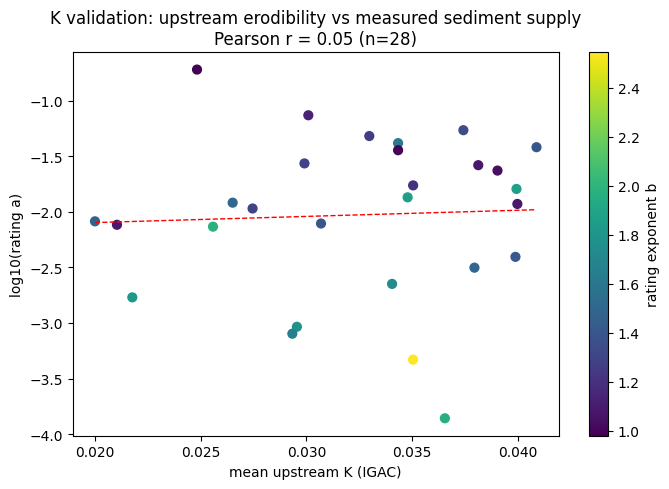

Pearson r(upstream K, log a) = 0.05  ->  INCONCLUSIVE (confounders dominate)
NOTE (honest): rating a is confounded by rainfall erosivity, slope, land cover, drainage area and reservoirs,
      and it trades off with the exponent b, so a is NOT a clean sediment-supply metric. A near-zero r means
      those confounders dominate over K here -- it does NOT show K is wrong. The definitive K validation is the
      full erosion model (K x LS x C x rainfall-erosivity) vs the measured sediment load in Phase B.


In [6]:
rc=pd.read_csv(proc/'rating_curves.csv'); gm=pd.read_csv(proc/'gauge_minibacia.csv')
mb=pd.read_csv(proc/'minibacias.csv')                      # id, area_km2, downstream
# per-minibacia mean K (area ~ equal-area cells at this grid)
kk=np.where(np.isnan(K),0,K); cnt=np.bincount(subs[bas],weights=(fam[bas]>0).astype(float),minlength=subs.max()+1)
ksum=np.bincount(subs[bas],weights=kk[bas],minlength=subs.max()+1)
Kmb=np.divide(ksum,cnt,out=np.zeros_like(ksum),where=cnt>0)   # index = minibacia id
# reverse topology: downstream -> list of upstream
from collections import defaultdict, deque
up=defaultdict(list)
for _,r in mb.iterrows(): up[int(r['downstream'])].append(int(r['id']))
def upstream_ids(start):
    seen=set([start]); q=deque([start])
    while q:
        x=q.popleft()
        for u in up.get(x,[]):
            if u not in seen: seen.add(u); q.append(u)
    return seen
code2mb=dict(zip(gm['code'].astype(int),gm['minibacia'].astype(int)))
rows=[]
for _,r in rc.iterrows():
    c=int(r['code']);
    if c not in code2mb: continue
    ids=upstream_ids(code2mb[c]); ids=[i for i in ids if i<len(Kmb) and Kmb[i]>0]
    if not ids: continue
    rows.append((c,r['a'],r['b'],r['R2'],np.mean([Kmb[i] for i in ids]),len(ids)))
val=pd.DataFrame(rows,columns=['code','a','b','R2','K_upstream','n_up'])
print(f'{len(val)} sediment gauges matched to a minibacia with upstream K')
if len(val)>=5:
    from numpy import log10, corrcoef
    x=val['K_upstream']; y=log10(val['a'].clip(lower=1e-6))
    r=corrcoef(x,y)[0,1]
    fig,ax=plt.subplots(figsize=(7,5))
    sc=ax.scatter(x,y,c=val['b'],cmap='viridis',s=40)
    m,bb=np.polyfit(x,y,1); xs=np.linspace(x.min(),x.max(),10); ax.plot(xs,m*xs+bb,'r--',lw=1)
    ax.set_xlabel('mean upstream K (IGAC)'); ax.set_ylabel('log10(rating a)')
    ax.set_title('K validation: upstream erodibility vs measured sediment supply\nPearson r = %.2f (n=%d)'%(r,len(val)))
    plt.colorbar(sc,ax=ax,label='rating exponent b'); plt.tight_layout(); plt.show()
    verd='supportive' if r>0.4 else ('weak positive' if r>0.15 else 'INCONCLUSIVE (confounders dominate)')
    print('Pearson r(upstream K, log a) = %.2f  ->  %s'%(r,verd))
    print('NOTE (honest): rating a is confounded by rainfall erosivity, slope, land cover, drainage area and reservoirs,')
    print('      and it trades off with the exponent b, so a is NOT a clean sediment-supply metric. A near-zero r means')
    print('      those confounders dominate over K here -- it does NOT show K is wrong. The definitive K validation is the')
    print('      full erosion model (K x LS x C x rainfall-erosivity) vs the measured sediment load in Phase B.')
else:
    print('too few matched gauges for a robust correlation; report as inconclusive')

## 6 — Per-minibacia parameter table (the model-ready output)

We aggregate to one row per minibacia: area-weighted mean **W<sub>m</sub>** and **K**, plus the dominant texture, mean
depth and dominant drainage. In the MGB run these attach to each URH by its soil family (from notebook 08); W<sub>m</sub>
then rides the discharge calibration, K stays pinned to these field-based values.

In [7]:
nid=subs.max()+1
def agg_mean(arr):
    a=np.where(np.isnan(arr),0,arr); c=np.bincount(subs[bas],weights=(~np.isnan(arr[bas])).astype(float),minlength=nid)
    s=np.bincount(subs[bas],weights=a[bas],minlength=nid)
    return np.divide(s,c,out=np.zeros_like(s),where=c>0)
Wm_mb=agg_mean(Wm); K_mb=agg_mean(K); Dep_mb=agg_mean(np.where(bas,dep_f,np.nan))
def dom(arr,classes):                       # vectorised dominant class per minibacia (no per-id mask loop)
    st=np.zeros((len(classes),nid))
    for j,k in enumerate(classes): st[j]=np.bincount(subs[bas&(arr==k)],minlength=nid)
    win=np.array(classes)[st.argmax(0)]; win[st.sum(0)==0]=0
    return win                               # indexed by minibacia id
domfam=dom(fam,[1,2,3]); domdr=dom(drn_f,[1,2,3])
ids=np.unique(subs[bas])
out=pd.DataFrame({'id':ids,
    'Wm_mm':np.round(Wm_mb[ids],1),'K':np.round(K_mb[ids],4),
    'depth_cm':np.round(Dep_mb[ids],0),
    'texture':[FAM.get(int(domfam[int(i)]),'') for i in ids],
    'drainage':[{1:'well',2:'moderate',3:'poor'}.get(int(domdr[int(i)]),'') for i in ids]})
out=out.merge(mb[['id','area_km2','downstream']],on='id',how='left')
out.to_csv(proc/'minibacia_soil_params.csv',index=False)
print('wrote data/processed/minibacia_soil_params.csv  (%d minibacias)'%len(out))
print(out.head(8).to_string(index=False))
print('\\nbasin means:  Wm %.0f mm   K %.3f   depth %.0f cm'%(out.Wm_mm.mean(),out.K.mean(),out.depth_cm.mean()))

wrote data/processed/minibacia_soil_params.csv  (8672 minibacias)
  id  Wm_mm      K  depth_cm texture drainage  area_km2  downstream
1174   51.8 0.0266      37.0    Fine     well     22.86        1195
1183   51.8 0.0266      37.0    Fine     well     25.03        1174
1195   51.8 0.0266      37.0    Fine     well     29.39        1219
1204   77.7 0.0318      51.0    Fine     well     26.67        1217
1210   55.6 0.0274      39.0    Fine     well     43.53        1393
1216   51.3 0.0266      36.0  Coarse     well     34.28        1217
1217   38.4 0.0241      29.0  Coarse     well     26.67        1218
1218   43.9 0.0253      32.0    Fine     well     34.83        1393
\nbasin means:  Wm 85 mm   K 0.032   depth 59 cm


## 7 — Summary & what is still calibrated

- **W<sub>m</sub>** and **K** now come **entirely from IGAC** (texture × depth for W<sub>m</sub>; texture × drainage for
  K), so the soil *classification* and the soil *parameters* are consistent, and neither inherits the SoilGrids
  near-uniform-clay artefact.
- **W<sub>m</sub>** is a physically-grounded **prior**; the split-sample discharge calibration (Phase B) will scale it
  per URH within literature bounds.
- **K** is *cross-checked* against the sediment rating curves now (a weak first look — the coefficient a is heavily
  confounded, so a near-zero correlation is expected and non-diagnostic); its definitive validation is the full erosion
  model vs measured load in Phase B, because calibration will not correct K the way it corrects W<sub>m</sub>.
- **Output:** `data/processed/minibacia_soil_params.csv` (W<sub>m</sub>, K, depth, texture, drainage per minibacia).

**Limitations (honest).** IGAC depth/texture words are ordinal, so W<sub>m</sub>/K take a few class-representative
levels rather than a continuum; AWC and K class values are literature mid-ranges (not local lab measurements); the
drainage→K factor is a small approximate adjustment. SoilGrids is still used only to fill the ~14 % of the basin IGAC
does not map. **Next — Phase B:** run the MGB-SA water balance with these parameters → simulated discharge, calibrated
on the IDEAM gauges (2011 La Niña vs 2015–16 El Niño).